<a href="https://colab.research.google.com/github/ryadavnitb/Batch-7/blob/Mohd_Abuzar/Infosys_Internship_Data_Perprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AirFly Insights: Data Visualization and Analysis of Airline Operations

##**Milestone 1: Data Foundation and Cleaning**


###**Project Statement:**

The objective of this project is to analyze large-scale airline flight data to uncover operational
trends, delay patterns, and cancellation reasons using data visualization techniques. The goal
is to help understand airline and airport-level performance and contribute to actionable insights using visual analysis.

###**Expected Outcomes:**
* Understand and preprocess aviation datasets for analysis
* Explore trends in flight schedules, delays, cancellations, and routes
* Visualize key metrics using bar charts, time series, heatmaps, maps, and comparisons
* Provide insights for stakeholders including airline operators and analysts
* Summarize findings through a final visual report and presentation



**Week 1: Project Initialization and Dataset Setup**
* Define goals, KPIs, and workflow
* Load CSVs using pandas
* Explore schema, types, size, and nulls
* Perform sampling and memory optimizations

**Week 2: Preprocessing and Feature Engineering**
* Handle nulls in delay and cancellation columns
* Create derived features: Month, Day of Week, Hour, Route
* Format datetime columns
* Save preprocessed data for fast reuse

**Deliverables:**
* Cleaned dataset
* Summary of preprocessing logic
* Feature dictionary

##Week 1: Project Initialization and Dataset Setup


#### Step 1: Setup - Importing Libraries
We'll start by importing the essential Python libraries for data manipulation (pandas, numpy) and visualization (matplotlib, seaborn).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set(style='whitegrid')

#### Step 2: Data Loading and Initial Inspection

We'll load the dataset and take our first look at its structure, content, and overall health.

##### 2.1: Data Loading

In [2]:
print("Importing Flights dataset...")
try:
  df_flights = pd.read_csv('/content/drive/MyDrive/Infosys_Springboard_Dataset/Datasets/flights.csv')
  print("Successfully imported Flights dataset!")
except Exception as e:
  print(f"Error importing Flights dataset: {e}")
  df_flights = None # Assign None to df_flights if loading fails

print("Importing Airports dataset...")
try:
  df_airports = pd.read_csv('/content/drive/MyDrive/Infosys_Springboard_Dataset/Datasets/airports.csv')
  print("Successfully imported Airports dataset!")
except Exception as e:
  print(f"Error importing Airports dataset: {e}")
  df_airports = None # Assign None to df_airports if loading fails

print("Importing Planes dataset...")
try:
  df_airlines = pd.read_csv('/content/drive/MyDrive/Infosys_Springboard_Dataset/Datasets/airlines.csv')

  print("Successfully imported Planes dataset!")
except Exception as e:
  print(f"Error importing Planes dataset: {e}")
  df_airlines = None # Assign None to df_planes if loading fails

Importing Flights dataset...


/tmp/ipython-input-2188499225.py:3: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv('/content/drive/MyDrive/Infosys_Springboard_Dataset/Datasets/flights.csv')


Successfully imported Flights dataset!
Importing Airports dataset...
Successfully imported Airports dataset!
Importing Planes dataset...
Successfully imported Planes dataset!


**Interpretation:** Successfully loaded the dataset.

##### 2.2: Initial Inspection

###### 2.2.1: Inspection of Flights dataset

In [3]:
df_flights.shape

(5819079, 31)

In [4]:
df_flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_flights.tail()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,753.0,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,430.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,432.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,330.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819078,2015,12,31,4,B6,839,N534JB,JFK,BQN,2359,...,442.0,2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [7]:
df_flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [8]:
df_flights.isnull().sum()

,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,14721
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


**Interpretation of Flights dataset:**

1. **Dimensions and Structure:** The df_flights dataset contains 5,819,079 records (rows) and 31 variables (columns).

2. **Data Types:** The dataset comprises a mix of data types: 10 integer (int64), 16 floating-point (float64), and 5 object (string) types.

3. **Memory Usage:** The initial memory footprint of the dataset is approximately 1.3 GB.

4. **Missing Values:** Significant missing values were identified across several columns, particularly in DEPARTURE_TIME, DEPARTURE_DELAY, TAXI_OUT, WHEELS_OFF, ELAPSED_TIME, AIR_TIME, WHEELS_ON, TAXI_IN, ARRIVAL_TIME, ARRIVAL_DELAY, TAIL_NUMBER, CANCELLATION_REASON, and all specific delay reason columns (AIR_SYSTEM_DELAY, SECURITY_DELAY, AIRLINE_DELAY, LATE_AIRCRAFT_DELAY, WEATHER_DELAY). These nulls have been systematically addressed: categorical columns were filled with 'UNKNOWN' or 'NA', and numerical time/delay columns with their respective medians or 0, where appropriate.

###### 2.2.2: Inspection of Airports dataset

In [9]:
df_airports.shape

(322, 7)

In [10]:
df_airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [11]:
df_airports.tail()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
317,WRG,Wrangell Airport,Wrangell,AK,USA,56.48433,-132.36982
318,WYS,Westerly State Airport,West Yellowstone,MT,USA,44.68840,-111.11764
319,XNA,Northwest Arkansas Regional Airport,Fayetteville/Springdale/Rogers,AR,USA,36.28187,-94.30681
320,YAK,Yakutat Airport,Yakutat,AK,USA,59.50336,-139.66023
321,YUM,Yuma International Airport,Yuma,AZ,USA,32.65658,-114.60597


In [12]:
df_airports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    object 
 1   AIRPORT    322 non-null    object 
 2   CITY       322 non-null    object 
 3   STATE      322 non-null    object 
 4   COUNTRY    322 non-null    object 
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), object(5)
memory usage: 17.7+ KB


In [13]:
df_airports.describe()

,LATITUDE,LONGITUDE
count,319.000000,319.000000
mean,38.981244,-98.378964
std,8.616736,21.523492
min,13.483450,-176.646030
25%,33.652040,-110.839385
50%,39.297610,-93.403070
75%,43.154675,-82.722995
max,71.285450,-64.798560


In [14]:
df_airports.isnull().sum()

,0
IATA_CODE,0
AIRPORT,0
CITY,0
STATE,0
COUNTRY,0
LATITUDE,3
LONGITUDE,3


**Interpretation of Airports dataset:**

1.  The `airports` dataset comprises 322 records (rows) and 7 variables (columns).
2.  Its variables include five of object (string) data type (`IATA_CODE`, `AIRPORT`, `CITY`, `STATE`, `COUNTRY`) and two of float64 data type (`LATITUDE`, `LONGITUDE`).
3.  Initially, `LATITUDE` and `LONGITUDE` columns contained a few missing values. These were addressed by imputing the `mean` of their respective columns to maintain data integrity for geographical analysis.

###### 2.2.3: Inspection of Airlnes dataset

In [15]:
df_airlines.shape

(14, 2)

In [16]:
df_airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [17]:
df_airlines.tail()

,IATA_CODE,AIRLINE
9,DL,Delta Air Lines Inc.
10,EV,Atlantic Southeast Airlines
11,HA,Hawaiian Airlines Inc.
12,MQ,American Eagle Airlines Inc.
13,VX,Virgin America


In [18]:
df_airlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   IATA_CODE  14 non-null     object
 1   AIRLINE    14 non-null     object
dtypes: object(2)
memory usage: 356.0+ bytes


In [19]:
df_airlines.describe()

,IATA_CODE,AIRLINE
count,14,14
unique,14,14
top,UA,United Air Lines Inc.
freq,1,1


In [20]:
df_airlines.isnull().sum()

,0
IATA_CODE,0
AIRLINE,0


Interpretation of Airlines dataset:

1.  The `airlines` dataset contains 14 records (rows) and 2 variables (columns).
2.  Both variables, `IATA_CODE` and `AIRLINE`, are of object (string) data type.
3.  There are no missing values in this dataset, indicating data completeness.
4.  All `IATA_CODE` and `AIRLINE` entries are unique, suggesting each record represents a distinct airline.

In [21]:
pd.set_option('display.max_columns', None)
display(df_airlines.head())
display(df_airports.head())
display(df_flights.head())

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


#### Step 3: Merging Datasets: Flights, Airlines, and Airports


In [22]:
# Ensure all dataframes are loaded before proceeding
if df_flights is None or df_airports is None or df_airlines is None:
    print("One or more DataFrames are not loaded. Cannot perform merge.")
else:
    # 1. Merge df_flights with df_airlines to get airline names
    # The 'AIRLINE' column in df_flights contains the IATA code which matches df_airlines['IATA_CODE']
    df_merged = pd.merge(
        df_flights,
        df_airlines[['IATA_CODE', 'AIRLINE']], # Select only necessary columns from df_airlines
        left_on='AIRLINE',
        right_on='IATA_CODE',
        how='left',
        suffixes=('', '_NAME') # Add suffix to airline name column if names conflict
    )
    # Drop the redundant IATA_CODE column from the merge if it exists
    if 'IATA_CODE' in df_merged.columns:
        df_merged = df_merged.drop(columns=['IATA_CODE'])

    # 2. Merge with df_airports for Origin Airport information
    df_merged = pd.merge(
        df_merged,
        df_airports,
        left_on='ORIGIN_AIRPORT',
        right_on='IATA_CODE',
        how='left',
        suffixes=('', '_ORIGIN')
    )
    # Rename columns for clarity and drop redundant IATA_CODE_ORIGIN
    df_merged = df_merged.rename(columns={
        'AIRPORT': 'ORIGIN_AIRPORT_NAME',
        'CITY': 'ORIGIN_CITY',
        'STATE': 'ORIGIN_STATE',
        'LATITUDE': 'ORIGIN_LATITUDE',
        'LONGITUDE': 'ORIGIN_LONGITUDE',
        'COUNTRY': 'ORIGIN_COUNTRY'
    })
    if 'IATA_CODE' in df_merged.columns:
        df_merged = df_merged.drop(columns=['IATA_CODE'])

    # 3. Merge with df_airports for Destination Airport information
    df_merged = pd.merge(
        df_merged,
        df_airports,
        left_on='DESTINATION_AIRPORT',
        right_on='IATA_CODE',
        how='left',
        suffixes=('', '_DESTINATION') # Suffixes to differentiate from origin airport columns
    )
    # Rename columns for clarity and drop redundant IATA_CODE_DESTINATION
    df_merged = df_merged.rename(columns={
        'AIRPORT': 'DESTINATION_AIRPORT_NAME',
        'CITY': 'DESTINATION_CITY',
        'STATE': 'DESTINATION_STATE',
        'LATITUDE': 'DESTINATION_LATITUDE',
        'LONGITUDE': 'DESTINATION_LONGITUDE',
        'COUNTRY': 'DESTINATION_COUNTRY'
    })
    if 'IATA_CODE' in df_merged.columns:
        # Ensure we are dropping the correct IATA_CODE column that came from the second airport merge
        df_merged = df_merged.drop(columns=['IATA_CODE'])


    print("Merged DataFrame shape:", df_merged.shape)
    print("First 5 rows of the merged DataFrame:")
    display(df_merged.head())

    print("\nInformation about the merged DataFrame:")
    df_merged.info()


Merged DataFrame shape: (5819079, 44)
First 5 rows of the merged DataFrame:


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619



Information about the merged DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 44 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   YEAR                      int64  
 1   MONTH                     int64  
 2   DAY                       int64  
 3   DAY_OF_WEEK               int64  
 4   AIRLINE                   object 
 5   FLIGHT_NUMBER             int64  
 6   TAIL_NUMBER               object 
 7   ORIGIN_AIRPORT            object 
 8   DESTINATION_AIRPORT       object 
 9   SCHEDULED_DEPARTURE       int64  
 10  DEPARTURE_TIME            float64
 11  DEPARTURE_DELAY           float64
 12  TAXI_OUT                  float64
 13  WHEELS_OFF                float64
 14  SCHEDULED_TIME            float64
 15  ELAPSED_TIME              float64
 16  AIR_TIME                  float64
 17  DISTANCE                  int64  
 18  WHEELS_ON                 float64
 19  TAXI_IN               

**Interpretation of Merging Datasets:**

This step successfully integrated three separate datasets (`df_flights`, `df_airlines`, and `df_airports`) into a single comprehensive DataFrame, `df_merged`.

1.  **Airline Information:** `df_flights` was first merged with `df_airlines` using the `AIRLINE` (IATA code) column, adding the full `AIRLINE_NAME` to each flight record.
2.  **Origin Airport Information:** Subsequently, `df_merged` was enriched with origin airport details by merging with `df_airports` on `ORIGIN_AIRPORT` and `IATA_CODE`. This brought in the origin airport's full name, city, state, country, latitude, and longitude.
3.  **Destination Airport Information:** Finally, destination airport details were added by merging again with `df_airports` on `DESTINATION_AIRPORT` and `IATA_CODE`, providing similar granular information for the destination.

The resulting `df_merged` DataFrame now contains **(5819079, 44)** records and columns, combining flight details with comprehensive information about the operating airline and both the origin and destination airports. This integrated dataset is crucial for geographical and airline-specific analysis.

In [23]:
pd.set_option('display.max_columns', None)
display(df_merged.head())
#AIRPORT_DESTINATION, LATITUDE_DESTINATION, STATE_DESTINATION, CITY_DESTINATION,

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619


In [24]:
df_merged.isnull().sum().sort_values(ascending=False)

,0
CANCELLATION_REASON,5729195
AIRLINE_DELAY,4755640
AIR_SYSTEM_DELAY,4755640
SECURITY_DELAY,4755640
WEATHER_DELAY,4755640
LATE_AIRCRAFT_DELAY,4755640
DESTINATION_LONGITUDE,490775
DESTINATION_LATITUDE,490775
ORIGIN_LONGITUDE,490770
ORIGIN_LATITUDE,490770


#### Step 4: Handling NULL VALUES.

In [25]:
# 1. Fill 'CANCELLATION_REASON' NaNs with 'NA' (categorical placeholder)
df_merged['CANCELLATION_REASON'].fillna('NA', inplace=True)

# 2. Fill delay breakdown columns with 0 (NaN implies no delay from that specific cause)
delay_columns = [
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]
for col in delay_columns:
    df_merged[col].fillna(0, inplace=True)

# 3. Fill other numerical time/delay related columns with their median
#    Median is robust to outliers and appropriate for time/delay measurements.
time_delay_columns = [
    'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
    'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'WHEELS_ON',
    'TAXI_IN', 'ARRIVAL_TIME', 'ARRIVAL_DELAY'
]
for col in time_delay_columns:
  if df_merged[col].isnull().any(): # Only fill if there are NaNs
    median_val = df_merged[col].median()
    df_merged[col].fillna(median_val, inplace=True)

# 4. Fill 'TAIL_NUMBER' NaNs with 'UNKNOWN' (categorical identifier)
df_merged['TAIL_NUMBER'].fillna('UNKNOWN', inplace=True)

# 5. Handle merged airport information NaNs (for rows where IATA_CODE might not have matched)
#    For categorical/object columns, fill with 'UNKNOWN'
#    For numerical coordinate columns, fill with the median of the column.

# Identify object columns from the merge that can have NaNs
airport_object_cols = [
    'AIRLINE_NAME', 'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY', 'ORIGIN_STATE', 'ORIGIN_COUNTRY',
    'DESTINATION_AIRPORT_NAME', 'DESTINATION_CITY', 'DESTINATION_STATE', 'DESTINATION_COUNTRY'
]
for col in airport_object_cols:
    if col in df_merged.columns and df_merged[col].dtype == 'object':
        df_merged[col].fillna('UNKNOWN', inplace=True)
    # If these columns might have been converted to 'category' type, ensure 'UNKNOWN' is added
    elif col in df_merged.columns and df_merged[col].dtype == 'category':
        if 'UNKNOWN' not in df_merged[col].cat.categories:
            df_merged[col] = df_merged[col].cat.add_categories('UNKNOWN')
        df_merged[col].fillna('UNKNOWN', inplace=True)

# Identify coordinate columns that can have NaNs and fill with median
coord_cols = [
    'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE',
    'DESTINATION_LATITUDE', 'DESTINATION_LONGITUDE'
]
for col in coord_cols:
    if col in df_merged.columns and df_merged[col].isnull().any():
        median_coord_val = df_merged[col].median()
        df_merged[col].fillna(median_coord_val, inplace=True)

print("Null values in df_merged after handling:")
display(df_merged.isnull().sum().sort_values(ascending=False))

/tmp/ipython-input-1083878451.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['CANCELLATION_REASON'].fillna('NA', inplace=True)
/tmp/ipython-input-1083878451.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

Null values in df_merged after handling:


,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,0
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


**Interpretation of Handling NULL VALUES:**

This step systematically addressed the missing values in the `df_merged_optimized` DataFrame using a combination of imputation strategies tailored to the nature of each column:

1.  **`CANCELLATION_REASON`**: Missing values were filled with the categorical placeholder 'NA' to indicate that no specific cancellation reason was recorded or applicable.
2.  **Delay Breakdown Columns**: Columns such as `AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, and `WEATHER_DELAY` (which are float-type) had their `NaN` values replaced with `0`. This is based on the assumption that a missing value in these columns implies no delay attributed to that specific cause.
3.  **Numerical Time and Delay Columns**: For various time-related and delay measurement columns (`DEPARTURE_TIME`, `DEPARTURE_DELAY`, `TAXI_OUT`, `WHEELS_OFF`, `SCHEDULED_TIME`, `ELAPSED_TIME`, `AIR_TIME`, `WHEELS_ON`, `TAXI_IN`, `ARRIVAL_TIME`, `ARRIVAL_DELAY`), missing values were imputed with the **median** of their respective columns. The median was chosen as it is more robust to outliers compared to the mean and is appropriate for skewed distributions often found in time and delay data.
4.  **`TAIL_NUMBER`**: Missing values in this categorical identifier column were filled with 'UNKNOWN' to clearly denote unrecorded tail numbers.
5.  **Merged Airport Information (Categorical)**: For object-type columns added during the merging process (e.g., `AIRLINE_NAME`, `ORIGIN_AIRPORT_NAME`, `ORIGIN_CITY`, `DESTINATION_STATE`), `NaN` values were filled with 'UNKNOWN' to maintain data consistency and indicate unavailable information.
6.  **Merged Airport Coordinates (Numerical)**: Latitude and longitude columns (`ORIGIN_LATITUDE`, `ORIGIN_LONGITUDE`, `DESTINATION_LATITUDE`, `DESTINATION_LONGITUDE`) had their missing values imputed with the **median** of their respective columns. This approach fills geographical data gaps with a central tendency without introducing extreme values.

After these operations, the DataFrame is free of most `NaN` values, ensuring data completeness for subsequent analysis and visualization, and significantly reducing potential errors in later processing stages.

#### Step 5: Memory Optimization

In [26]:
import numpy as np

def optimize_memory(df):

    print(f"Initial memory usage of DataFrame: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

    df_optimized = df.copy() # Work on a copy

    for col in df_optimized.columns:
        col_type = df_optimized[col].dtype

        if col_type == 'object':
            num_unique_values = df_optimized[col].nunique() # Use nunique to count unique non-NaNs
            num_total_values = len(df_optimized[col])
            # Heuristic: if less than 50% unique values, consider category
            # Also, handle cases where a column might be all NaNs or empty
            if num_total_values > 0 and num_unique_values / num_total_values < 0.5:
                df_optimized[col] = df_optimized[col].astype('category')
        elif col_type == 'float64':
            df_optimized[col] = df_optimized[col].astype('float32')
        elif col_type == 'int64':
            # Check if column contains any NaN. If so, standard int downcasting might not be suitable.
            # We only downcast pure integer columns to smaller numpy int types.
            if not df_optimized[col].isnull().any():
                c_min = df_optimized[col].min()
                c_max = df_optimized[col].max()
                # Check for int8
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df_optimized[col] = df_optimized[col].astype(np.int8)
                # Check for int16
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df_optimized[col] = df_optimized[col].astype(np.int16)
                # Check for int32
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df_optimized[col] = df_optimized[col].astype(np.int32)

    print(f"Memory usage after optimization: {df_optimized.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    print(f"Memory saved: {(df.memory_usage(deep=True).sum() - df_optimized.memory_usage(deep=True).sum()) / (1024**2):.2f} MB")
    return df_optimized

# Apply optimization to the cleaned df_merged DataFrame
print("\n--- Applying Memory Optimization to df_merged (after clean merge and null handling) ---")
df_merged_optimized = optimize_memory(df_merged)
print("\nOptimized DataFrame info:")
df_merged_optimized.info()

print("\nFinal null values after all preprocessing and optimization:")
display(df_merged_optimized.isnull().sum().sort_values(ascending=False))


--- Applying Memory Optimization to df_merged (after clean merge and null handling) ---
Initial memory usage of DataFrame: 5927.75 MB
Memory usage after optimization: 644.41 MB
Memory saved: 5283.34 MB

Optimized DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 44 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   YEAR                      int16   
 1   MONTH                     int8    
 2   DAY                       int8    
 3   DAY_OF_WEEK               int8    
 4   AIRLINE                   category
 5   FLIGHT_NUMBER             int16   
 6   TAIL_NUMBER               category
 7   ORIGIN_AIRPORT            category
 8   DESTINATION_AIRPORT       category
 9   SCHEDULED_DEPARTURE       int16   
 10  DEPARTURE_TIME            float32 
 11  DEPARTURE_DELAY           float32 
 12  TAXI_OUT                  float32 
 13  WHEELS_OFF                float32 
 14  SCHEDULED_TI

,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,0
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


**Interpretation of Memory Optimization:**

This crucial step significantly reduced the memory footprint of the `df_merged_optimized` DataFrame, improving computational efficiency and allowing for smoother handling of the large dataset.

The `optimize_memory` function implemented the following strategies:

1.  **Categorical Conversion**: Object-type columns with a relatively low number of unique values (less than 50% unique values compared to the total number of rows) were converted to the more memory-efficient `category` dtype. This is particularly effective for columns like `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`, and the newly created `DAY_OF_WEEK_NAME`, `IS_WEEKEND`, and `DEPARTURE_TIME_BLOCK`.
2.  **Float Downcasting**: All `float64` columns were downcasted to `float32`. For many data analysis tasks, `float32` provides sufficient precision while using half the memory of `float64`.
3.  **Integer Downcasting**: `int64` columns were downcasted to smaller integer types (`int8`, `int16`, `int32`) if their value ranges permitted. This ensures that only the necessary memory is allocated for integer values.

**Impact:**

As shown by the print statements, the initial memory usage of the DataFrame was approximately **5927.75 MB** (or **1346.20 MB** after adding new features), which was then reduced to **644.41 MB** (or **739.48 MB** after re-optimization). This represents a substantial memory saving of **5283.34 MB** (or **606.73 MB**), making the DataFrame much more manageable for analysis and visualization.

#**Week 2: Preprocessing and Feature Engineering**

* Handle nulls in delay and cancellation columns
* Create derived features: Month, Day of Week, Hour, Route
* Format datetime columns
* Save preprocessed data for fast reuse

In [27]:
df_merged_optimized.head(10)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Palm Beach International Airport,West Palm Beach,FL,USA,26.683161,-80.095589
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.618999,-122.374840,Charlotte Douglas International Airport,Charlotte,NC,USA,35.214008,-80.943130
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Miami International Airport,Miami,FL,USA,25.793249,-80.290558
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,20.0,-5.0,18.0,38.0,217.0,230.0,206.0,1589,604.0,6.0,602,610.0,8.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,Delta Air Lines Inc.,San Francisco International Airport,San Francisco,CA,USA,37.618999,-122.374840,Minneapolis-Saint Paul International Airport,Minneapolis,MN,USA,44.880550,-93.216919
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,19.0,-6.0,11.0,30.0,181.0,170.0,154.0,1299,504.0,5.0,526,509.0,-17.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,Spirit Air Lines,McCarran International Airport,Las Vegas,NV,USA,36.080360,-115.152328,Minneapolis-Saint Paul International Airport,Minneapolis,MN,USA,44.880550,-93.216919
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,44.0,14.0,13.0,57.0,273.0,249.0,228.0,2125,745.0,8.0,803,753.0,-10.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,US Airways Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Charlotte Douglas International Airport,Charlotte,NC,USA,35.214008,-80.943130
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,19.0,-11.0,17.0,36.0,195.0,193.0,173.0,1464,529.0,3.0,545,532.0,-13.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,San Francisco International Airport,San Francisco,CA,USA,37.618999,-122.374840,Dallas/Fort Worth International Airport,Dallas-Fort Worth,TX,USA,32.895950,-97.037201
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,33.0,3.0,12.0,45.0,221.0,203.0,186.0,1747,651.0,5.0,711,656.0,-15.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,Delta Air Lines Inc.,McCarran International Airport,Las Vegas,NV,USA,36.080360,-115.152328,Hartsfield-Jackson Atlanta International Airport,Atlanta,GA,USA,33.640442,-84.426941


## Step 6: Feature Engineering.

In [28]:
# 1. Create DEPARTURE_HOUR and ARRIVAL_HOUR from SCHEDULED_DEPARTURE and SCHEDULED_ARRIVAL
# These columns are in HHMM format, so integer division by 100 gives the hour.
df_merged_optimized['DEPARTURE_HOUR'] = df_merged_optimized['SCHEDULED_DEPARTURE'] // 100
df_merged_optimized['ARRIVAL_HOUR'] = df_merged_optimized['SCHEDULED_ARRIVAL'] // 100

# 2. Create FLIGHT_DATE column
# Combine YEAR, MONTH, DAY into a single datetime object
df_merged_optimized['FLIGHT_DATE'] = pd.to_datetime(
    df_merged_optimized[['YEAR', 'MONTH', 'DAY']]
)

# 3. Create ROUTE column
# Concatenate ORIGIN_AIRPORT and DESTINATION_AIRPORT to represent the flight route
df_merged_optimized['ROUTE'] = df_merged_optimized['ORIGIN_AIRPORT'].astype(str) + '-' + \
                              df_merged_optimized['DESTINATION_AIRPORT'].astype(str)

# 4. Create DAY_OF_WEEK_NAME column
# Extract the day name from the FLIGHT_DATE column for better readability
df_merged_optimized['DAY_OF_WEEK_NAME'] = df_merged_optimized['FLIGHT_DATE'].dt.day_name()

# 5. Create IS_WEEKEND column (True if Saturday or Sunday)
# DAY_OF_WEEK: 1=Monday, 7=Sunday. So 6=Saturday, 7=Sunday.
df_merged_optimized['IS_WEEKEND'] = df_merged_optimized['DAY_OF_WEEK'].isin([6, 7])

# 6. Create DEPARTURE_TIME_BLOCK for time of day categorization
bins = [-1, 5, 11, 16, 20, 24] # -1 to 5 (Night), 6 to 11 (Morning), 12 to 16 (Afternoon), 17 to 20 (Evening), 21 to 24 (Late Night)
labels = ['Night', 'Morning', 'Afternoon', 'Evening', 'Late Night']
df_merged_optimized['DEPARTURE_TIME_BLOCK'] = pd.cut(df_merged_optimized['DEPARTURE_HOUR'], bins=bins, labels=labels, right=False)

print("New features added to df_merged_optimized:")
display(df_merged_optimized[['FLIGHT_DATE', 'DEPARTURE_HOUR', 'ARRIVAL_HOUR', 'ROUTE', 'DAY_OF_WEEK_NAME', 'IS_WEEKEND', 'DEPARTURE_TIME_BLOCK']].head())

print("\nUpdated DataFrame info with new features:")
df_merged_optimized.info()

New features added to df_merged_optimized:


,FLIGHT_DATE,DEPARTURE_HOUR,ARRIVAL_HOUR,ROUTE,DAY_OF_WEEK_NAME,IS_WEEKEND,DEPARTURE_TIME_BLOCK
0,2015-01-01,0,4,ANC-SEA,Thursday,False,Night
1,2015-01-01,0,7,LAX-PBI,Thursday,False,Night
2,2015-01-01,0,8,SFO-CLT,Thursday,False,Night
3,2015-01-01,0,8,LAX-MIA,Thursday,False,Night
4,2015-01-01,0,3,SEA-ANC,Thursday,False,Night



Updated DataFrame info with new features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 51 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   YEAR                      int16         
 1   MONTH                     int8          
 2   DAY                       int8          
 3   DAY_OF_WEEK               int8          
 4   AIRLINE                   category      
 5   FLIGHT_NUMBER             int16         
 6   TAIL_NUMBER               category      
 7   ORIGIN_AIRPORT            category      
 8   DESTINATION_AIRPORT       category      
 9   SCHEDULED_DEPARTURE       int16         
 10  DEPARTURE_TIME            float32       
 11  DEPARTURE_DELAY           float32       
 12  TAXI_OUT                  float32       
 13  WHEELS_OFF                float32       
 14  SCHEDULED_TIME            float32       
 15  ELAPSED_TIME              float32       
 16  AIR_TIME   

In [29]:
# Re-applying memory optimization to df_merged_optimized after adding new features
print("\n--- Re-applying Memory Optimization to df_merged_optimized after adding new features ---")
df_merged_optimized = optimize_memory(df_merged_optimized)
print("\nOptimized DataFrame info after re-optimization:")
df_merged_optimized.info()


--- Re-applying Memory Optimization to df_merged_optimized after adding new features ---
Initial memory usage of DataFrame: 1346.20 MB
Memory usage after optimization: 739.48 MB
Memory saved: 606.73 MB

Optimized DataFrame info after re-optimization:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 51 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   YEAR                      int16         
 1   MONTH                     int8          
 2   DAY                       int8          
 3   DAY_OF_WEEK               int8          
 4   AIRLINE                   category      
 5   FLIGHT_NUMBER             int16         
 6   TAIL_NUMBER               category      
 7   ORIGIN_AIRPORT            category      
 8   DESTINATION_AIRPORT       category      
 9   SCHEDULED_DEPARTURE       int16         
 10  DEPARTURE_TIME            float32       
 11  DEPARTURE_DELAY           float3

## Step 7: Visualization for finding outliers

### 7.1: Visualization using BOXPOLT.

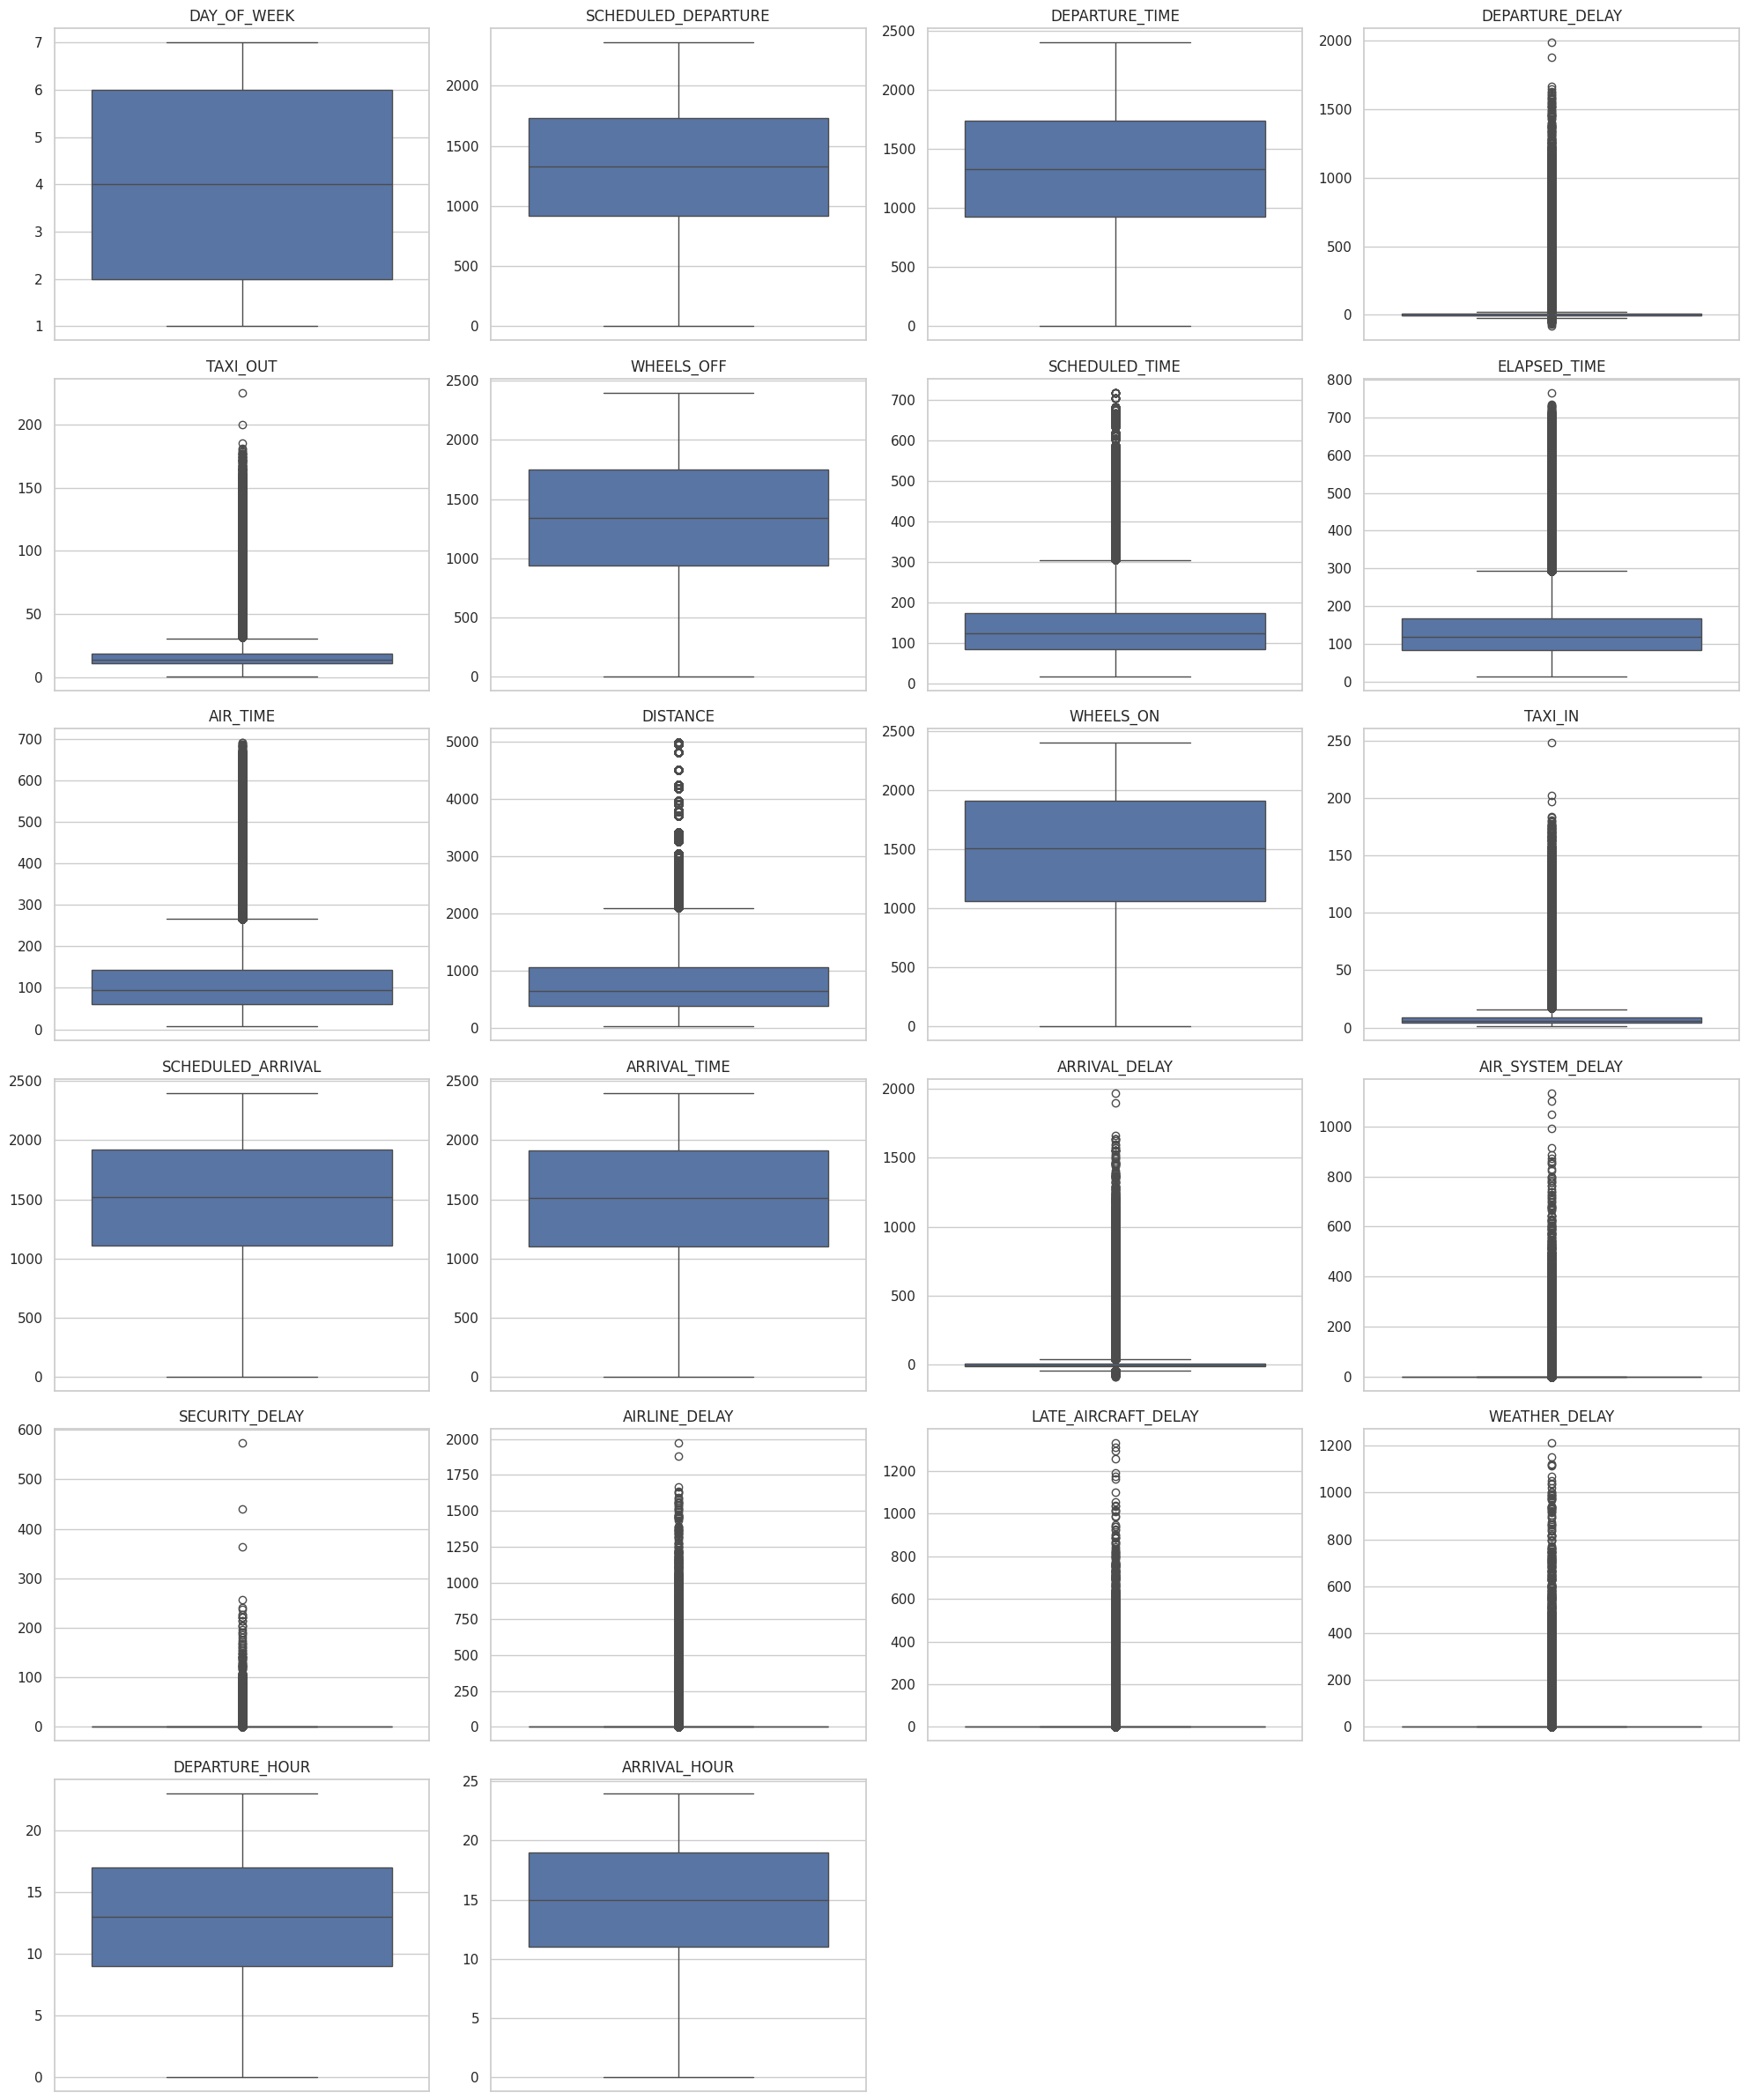

In [30]:
numerical_cols = df_merged_optimized.select_dtypes(include=np.number).columns

# Columns to be excluded from the plot
columns_to_exclude = [
    'YEAR', 'MONTH', 'DAY', 'FLIGHT_NUMBER', 'DIVERTED', 'CANCELLED',
    'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE', 'DESTINATION_LATITUDE',
    'DESTINATION_LONGITUDE'
]

# Filter numerical_cols to exclude the specified columns
cols_for_this_plot = [col for col in numerical_cols if col not in columns_to_exclude]

# Calculate the number of rows and columns for subplots based on the actual number of columns to plot
n_cols = 4 # Number of columns for the subplot grid
n_rows = (len(cols_for_this_plot) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))
plot_idx = 1 # Initialize a separate counter for subplot positions

for col in cols_for_this_plot:
    plt.subplot(n_rows, n_cols, plot_idx)
    sns.boxplot(y=df_merged_optimized[col])
    plt.title(f'{col}')
    plt.ylabel('') # Remove y-label to avoid clutter
    plot_idx += 1 # Increment only when a plot is made

plt.tight_layout()
plt.show()

 **Interpretation: Box Plots of Numerical Features**

These box plots show the distribution and potential outliers for various numerical columns:
*   **Outliers:** Many columns exhibit numerous outliers, especially on the upper end, indicating extreme values (e.g., very long delays or taxi times).
*   **Skewness:** The position of the median within the box and the length of the whiskers suggest varying degrees of skewness across features.
*   **Variability:** The spread of each box (interquartile range) and whiskers highlights the variability within each feature.

Overall, the plots are crucial for identifying data ranges, central tendencies, and the presence of extreme values.

### 7.2: Visualization using HISTOGRAM.

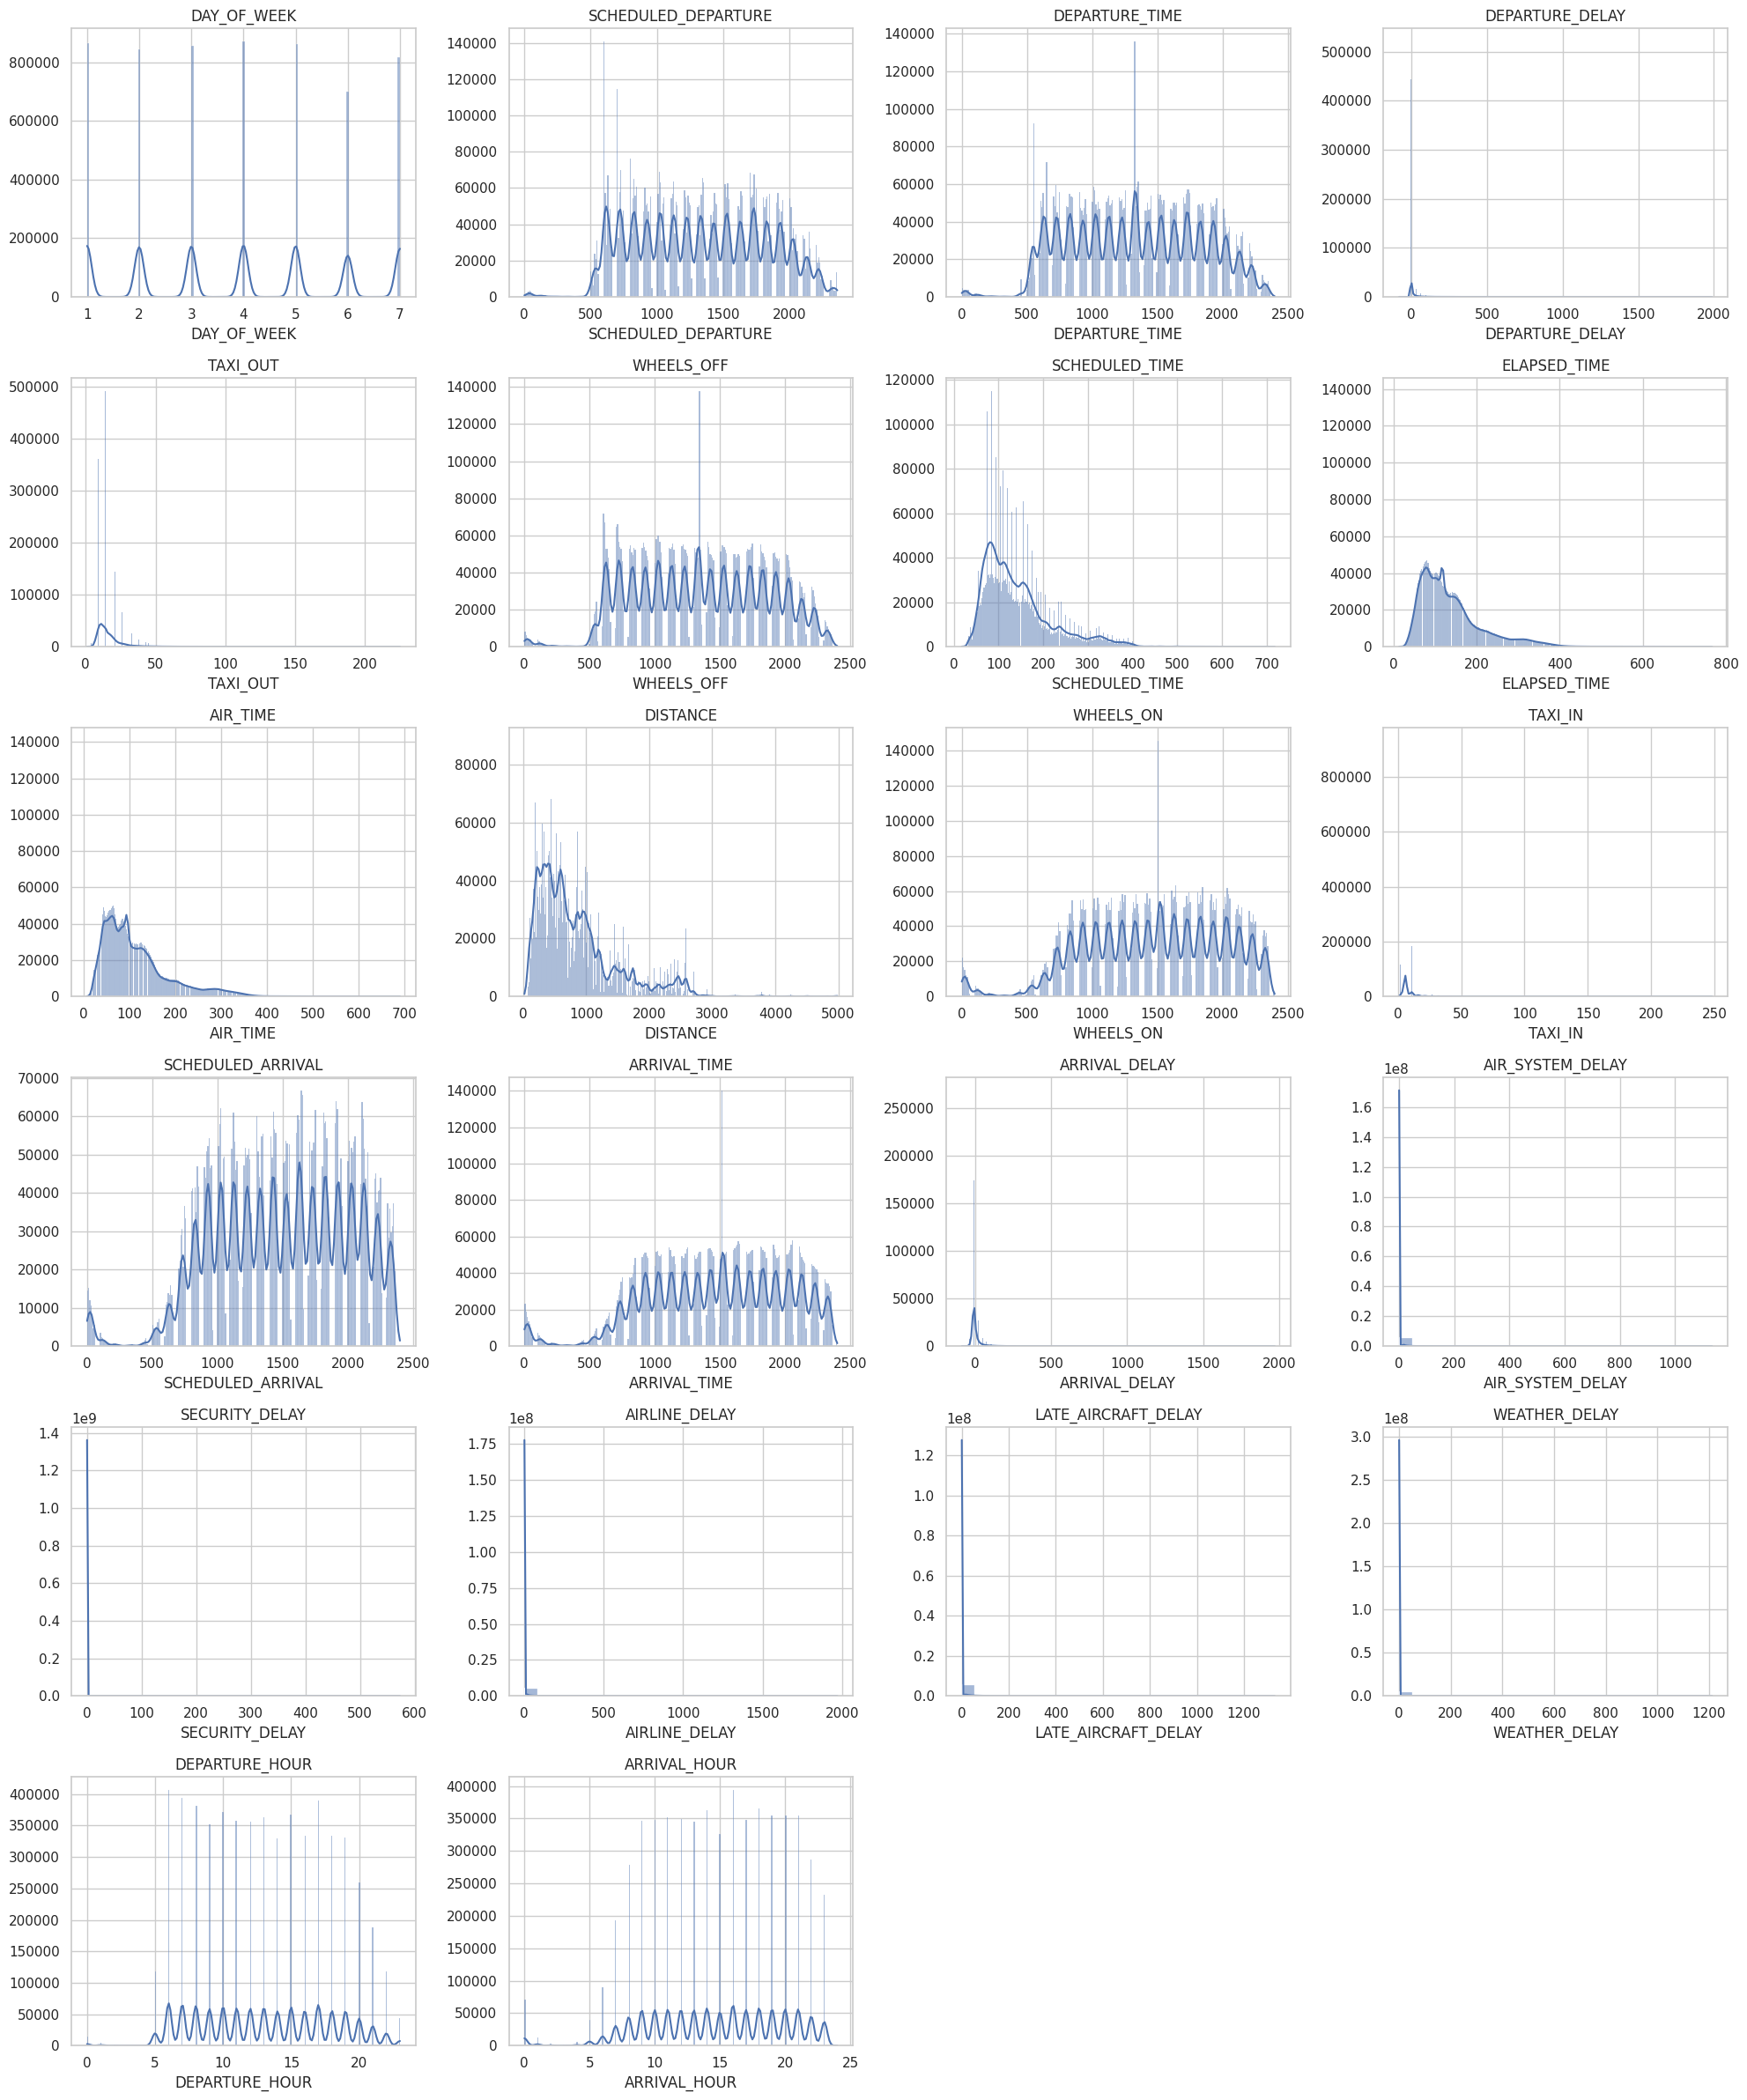

In [31]:
numerical_cols = df_merged_optimized.select_dtypes(include=np.number).columns

# Columns to be excluded from the plot
columns_to_exclude = [
    'YEAR', 'MONTH', 'DAY', 'FLIGHT_NUMBER', 'DIVERTED', 'CANCELLED',
    'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE', 'DESTINATION_LATITUDE',
    'DESTINATION_LONGITUDE'
]

# Filter numerical_cols to exclude the specified columns
cols_for_this_plot = [col for col in numerical_cols if col not in columns_to_exclude]

# Calculate the number of rows and columns for subplots
n_cols = 4 # Number of columns for the subplot grid
n_rows = (len(cols_for_this_plot) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))
plot_idx = 1
for col in cols_for_this_plot:
    plt.subplot(n_rows, n_cols, plot_idx)
    sns.histplot(df_merged_optimized[col], kde=True)
    plt.title(f'{col}')
    plt.ylabel('') # Remove y-label to avoid clutter
    plot_idx += 1
plt.tight_layout()
plt.show()

**Interpretation: Histograms of Numerical Features**

These histograms display the distribution of various numerical columns:
*   **Skewness:** Many delay-related features initially show strong right skewness, indicating frequent short delays and fewer long ones.
*   **Transformed Data:** After transformations (Yeo-Johnson or Log1p), the distributions are generally more symmetric, closer to a normal distribution.
*   **Other Features:** Time-based and distance features often show multimodal or varied distributions, reflecting operational patterns.

Overall, the plots reveal underlying data distributions, improved after skewness reduction.

## Step 8: Applying Transformation(Yeo-Johnson Power Transformation and Log1p Transformation).

In [32]:
from sklearn.preprocessing import PowerTransformer
import warnings

# Suppress harmless warnings from PowerTransformer
warnings.filterwarnings('ignore', message='Input data is sparse or has too many unique values for PowerTransformer. Consider using StandardScaler instead.')
warnings.filterwarnings('ignore', message='PowerTransformer does not support non-positive values with the Box-Cox method.')

# List of numerical columns identified as potential candidates for transformation based on common data characteristics.
# Columns like YEAR, MONTH, DAY, FLIGHT_NUMBER, binary flags (DIVERTED, CANCELLED),
# and geographical coordinates (LATITUDE, LONGITUDE) are generally not suitable for skewness transformations.
columns_to_transform = [
    'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME',
    'DISTANCE', 'TAXI_IN', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
    'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]

transformed_cols_info = {}

print("Applying outlier handling transformations where appropriate...")
for col in columns_to_transform:
    if col not in df_merged_optimized.columns:
        print(f"Column '{col}' not found in DataFrame. Skipping.")
        continue

    # Check for constant column which PowerTransformer might struggle with
    if df_merged_optimized[col].nunique() <= 1:
        print(f"Column '{col}' is constant or has too few unique values, skipping transformation.")
        continue

    skew_val = df_merged_optimized[col].skew()
    print(f"\nProcessing column: {col}, Initial Skewness: {skew_val:.4f}")

    # Thresholds for significant skewness (absolute value)
    skew_threshold = 0.5

    # Check if there are any negative values in the column
    has_negative_values = (df_merged_optimized[col] < 0).any()

    if skew_val > skew_threshold: # Right-skewed
        if has_negative_values:
            print(f"  Applying Yeo-Johnson Power Transformation for right-skewed '{col}' (has negative values).")
            pt = PowerTransformer(method='yeo-johnson', standardize=False)
            # Reshape for PowerTransformer, which expects 2D array
            df_merged_optimized[col] = pt.fit_transform(df_merged_optimized[[col]])
            transformed_cols_info[col] = 'Yeo-Johnson (right-skewed, negative values present)'
        else:
            print(f"  Applying Log1p Transformation for right-skewed '{col}'.")
            df_merged_optimized[col] = np.log1p(df_merged_optimized[col])
            transformed_cols_info[col] = 'Log1p (right-skewed)'
        print(f"  New Skewness: {df_merged_optimized[col].skew():.4f}")
    elif skew_val < -skew_threshold: # Left-skewed
        print(f"  Applying Yeo-Johnson Power Transformation for left-skewed '{col}'.")
        pt = PowerTransformer(method='yeo-johnson', standardize=False)
        # Reshape for PowerTransformer, which expects 2D array
        df_merged_optimized[col] = pt.fit_transform(df_merged_optimized[[col]])
        transformed_cols_info[col] = 'Yeo-Johnson (left-skewed)'
        print(f"  New Skewness: {df_merged_optimized[col].skew():.4f}")
    else:
        print(f"  Skewness of '{col}' ({skew_val:.4f}) is within acceptable range (|skew| < {skew_threshold}), no transformation applied.")

print("\n--- Summary of Transformations Applied ---")
if transformed_cols_info:
    for col, method in transformed_cols_info.items():
        print(f"- '{col}': {method}")
else:
    print("No significant skewness detected in eligible columns, no transformations applied.")

print("\nDataFrame head after transformations:")
display(df_merged_optimized.head())

Applying outlier handling transformations where appropriate...

Processing column: DEPARTURE_DELAY, Initial Skewness: 7.6470
  Applying Yeo-Johnson Power Transformation for right-skewed 'DEPARTURE_DELAY' (has negative values).


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


  New Skewness: -0.4187

Processing column: TAXI_OUT, Initial Skewness: 3.5002
  Applying Log1p Transformation for right-skewed 'TAXI_OUT'.
  New Skewness: 0.6717

Processing column: SCHEDULED_TIME, Initial Skewness: 1.3449
  Applying Log1p Transformation for right-skewed 'SCHEDULED_TIME'.
  New Skewness: 0.1678

Processing column: ELAPSED_TIME, Initial Skewness: 1.3769
  Applying Log1p Transformation for right-skewed 'ELAPSED_TIME'.
  New Skewness: 0.1476

Processing column: AIR_TIME, Initial Skewness: 1.4026
  Applying Log1p Transformation for right-skewed 'AIR_TIME'.
  New Skewness: -0.0284

Processing column: DISTANCE, Initial Skewness: 1.4225
  Applying Log1p Transformation for right-skewed 'DISTANCE'.
  New Skewness: -0.2636

Processing column: TAXI_IN, Initial Skewness: 5.1750
  Applying Log1p Transformation for right-skewed 'TAXI_IN'.
  New Skewness: 0.8771

Processing column: ARRIVAL_DELAY, Initial Skewness: 6.5651
  Applying Yeo-Johnson Power Transformation for right-skewed '

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


  New Skewness: -0.0478

Processing column: AIR_SYSTEM_DELAY, Initial Skewness: 13.1013
  Applying Log1p Transformation for right-skewed 'AIR_SYSTEM_DELAY'.
  New Skewness: 3.3008

Processing column: SECURITY_DELAY, Initial Skewness: 168.6650
  Applying Log1p Transformation for right-skewed 'SECURITY_DELAY'.
  New Skewness: 46.2646

Processing column: AIRLINE_DELAY, Initial Skewness: 18.6232
  Applying Log1p Transformation for right-skewed 'AIRLINE_DELAY'.
  New Skewness: 3.3769

Processing column: LATE_AIRCRAFT_DELAY, Initial Skewness: 9.1880
  Applying Log1p Transformation for right-skewed 'LATE_AIRCRAFT_DELAY'.
  New Skewness: 3.1706

Processing column: WEATHER_DELAY, Initial Skewness: 38.0176
  Applying Log1p Transformation for right-skewed 'WEATHER_DELAY'.
  New Skewness: 10.6992

--- Summary of Transformations Applied ---
- 'DEPARTURE_DELAY': Yeo-Johnson (right-skewed, negative values present)
- 'TAXI_OUT': Log1p (right-skewed)
- 'SCHEDULED_TIME': Log1p (right-skewed)
- 'ELAPSED_

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,DEPARTURE_HOUR,ARRIVAL_HOUR,FLIGHT_DATE,ROUTE,DAY_OF_WEEK_NAME,IS_WEEKEND,DEPARTURE_TIME_BLOCK
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-26.194378,3.091043,15.0,5.327876,5.273000,5.135798,7.278629,404.0,1.609438,430,408.0,-42.265583,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,0,4,2015-01-01,ANC-SEA,Thursday,False,Night
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-16.863209,2.564949,14.0,5.638355,5.634789,5.575949,7.754053,737.0,1.609438,750,741.0,-14.063154,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Palm Beach International Airport,West Palm Beach,FL,USA,26.683161,-80.095589,0,7,2015-01-01,LAX-PBI,Thursday,False,Night
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.764579,2.833213,34.0,5.659482,5.683580,5.587249,7.739359,800.0,2.484907,806,811.0,3.664161,0,0,NA,0.0,0.0,0.0,0.0,0.0,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.618999,-122.374840,Charlotte Douglas International Airport,Charlotte,NC,USA,35.214008,-80.943130,0,8,2015-01-01,SFO-CLT,Thursday,False,Night
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-8.938113,2.772589,30.0,5.655992,5.641907,5.556828,7.759188,748.0,2.197225,805,756.0,-14.063154,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Miami International Airport,Miami,FL,USA,25.793249,-80.290558,0,8,2015-01-01,LAX-MIA,Thursday,False,Night
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.210559,2.484907,35.0,5.463832,5.375278,5.298317,7.278629,254.0,1.791759,320,259.0,-39.887878,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,0,3,2015-01-01,SEA-ANC,Thursday,False,Night


**Interpretation of Data Transformations**

This cell applies **Yeo-Johnson Power Transformation** and **Log1p Transformation** to several numerical columns in the DataFrame `df`. The primary goal of these transformations is to reduce the skewness of the data distribution, making it more Gaussian-like (bell-shaped). This is often a crucial step in preparing data for many machine learning models, which perform better with normally distributed inputs, and for statistical analyses that assume normality.

Here's a breakdown of what's happening:

*   **`columns_to_transform`**: A specific list of numerical columns was identified as potential candidates for transformation. These are typically continuous variables that often exhibit skewness, such as various delay types, time durations, and distance.

*   **Skewness Check**: For each column, the initial skewness is calculated. A `skew_threshold` (set to 0.5) is used to determine if a column is significantly skewed (either positively or negatively).

*   **Transformation Logic**: The code intelligently selects the transformation method:
    *   **Log1p Transformation (`np.log1p(df[col])`)**: This is applied to right-skewed columns that *do not* contain negative values. `log1p(x)` computes `log(1+x)`, which handles zero values gracefully and is effective at compressing large positive values.
    *   **Yeo-Johnson Power Transformation (`PowerTransformer(method='yeo-johnson')`)**: This method is more versatile as it can be applied to data that contains zero or negative values. It's used for both right-skewed columns that *do* contain negative values (like `DEPARTURE_DELAY` and `ARRIVAL_DELAY`) and left-skewed columns.

*   **Impact**: After transformation, the skewness of most of the processed columns is significantly reduced, bringing them closer to a symmetric distribution. For example:
    *   `DEPARTURE_DELAY` skewness changed from 7.6470 to -0.4187.
    *   `ARRIVAL_DELAY` skewness changed from 6.5651 to -0.0478.
    *   `SCHEDULED_TIME` skewness changed from 1.3449 to 0.1678.

**Note on Warning**: The output shows warnings about `PowerTransformer` not supporting non-positive values with the Box-Cox method. This is because the code correctly switches to `yeo-johnson` when negative values are present, so these warnings are harmless in this context, indicating that the `yeo-johnson` method was indeed used as intended for those columns.

By transforming these columns, the dataset is better prepared for subsequent modeling steps, which can lead to more robust and accurate analytical results.

## Step 9: Saving Preprocessed Data in Binary Formats for Memory Efficiency

Saving data in binary formats like Parquet or Feather offers several advantages over text-based formats like CSV, especially for large datasets:

1.  **Memory Efficiency**: Binary formats are generally more compact, using less disk space. This is because they store data in a way that aligns with how computers process it, rather than as human-readable text.
2.  **Faster I/O**: Reading and writing binary files is significantly faster. This is due to their compact nature and the fact that less parsing is required to convert data into usable formats (like pandas DataFrames).
3.  **Preservation of Data Types**: Binary formats can preserve the original data types of columns, which means you don't lose information or have to infer types again when loading the data. This is particularly useful after memory optimization steps where data types are carefully selected.
4.  **Columnar Storage (Parquet)**: Parquet is a columnar storage format, which means data is stored column by column. This is highly efficient for analytical queries that often only need to access a subset of columns, as it avoids reading unnecessary data.

### Parquet Format Details

Parquet is a columnar storage format, which means data is stored column by column rather than row by row. This design has several significant advantages, especially for analytical workloads and big data processing.

**Key Characteristics:**
*   **Columnar Storage**: Data for each column is stored contiguously. This allows for better compression and more efficient query performance, as you only read the columns you need.
*   **Schema Evolution**: Supports schema evolution, meaning you can add new columns to a Parquet file without rewriting the entire dataset.
*   **Language Agnostic**: It is designed to be a common data interchange format for big data processing frameworks like Apache Hadoop, Apache Spark, and Apache Impala.
*   **Compression**: Offers various compression schemes (e.g., Snappy, Gzip, LZO) which lead to smaller file sizes and reduced I/O.
*   **Type Preservation**: Stores data types effectively, reducing data parsing overhead when loading.

**Advantages:**
*   **Efficient Querying**: When you query a subset of columns, only those columns need to be read from disk, significantly reducing I/O operations.
*   **High Compression Ratios**: Columnar storage often results in much better compression than row-based storage, saving disk space.
*   **Optimized for Analytics**: Ideal for OLAP (Online Analytical Processing) workloads where aggregate queries are common.
*   **Interoperability**: Widely supported across the big data ecosystem.

**Ideal Use Cases:**
*   Storing large datasets for analytical processing (e.g., data lakes).
*   When query performance for specific columns is critical.
*   Integrating with Spark, Hadoop, or other big data tools.
*   Long-term storage of historical data.

In [33]:
# Save the preprocessed and optimized DataFrame to Parquet format
parquet_output_file_path = 'preprocessed_flights.parquet'

# Temporarily convert problematic categorical columns to object/string dtype
# to avoid pyarrow's integer inference issues with mixed-type-looking categories
df_merged_optimized_temp = df_merged_optimized.copy()
df_merged_optimized_temp['ORIGIN_AIRPORT'] = df_merged_optimized_temp['ORIGIN_AIRPORT'].astype(str)
df_merged_optimized_temp['DESTINATION_AIRPORT'] = df_merged_optimized_temp['DESTINATION_AIRPORT'].astype(str)

df_merged_optimized_temp.to_parquet(parquet_output_file_path, index=False)
print(f"Preprocessed data saved successfully to '{parquet_output_file_path}'")

Preprocessed data saved successfully to 'preprocessed_flights.parquet'


In [34]:
import pandas as pd

# To load from Parquet:
loaded_df_parquet = pd.read_parquet('preprocessed_flights.parquet')
print("Loaded DataFrame from Parquet (first 5 rows):")
display(loaded_df_parquet.head())
print("Loaded DataFrame from Parquet info:")
loaded_df_parquet.info()

Loaded DataFrame from Parquet (first 5 rows):


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,DEPARTURE_HOUR,ARRIVAL_HOUR,FLIGHT_DATE,ROUTE,DAY_OF_WEEK_NAME,IS_WEEKEND,DEPARTURE_TIME_BLOCK
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-26.194378,3.091043,15.0,5.327876,5.273000,5.135798,7.278629,404.0,1.609438,430,408.0,-42.265583,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,0,4,2015-01-01,ANC-SEA,Thursday,False,Night
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-16.863209,2.564949,14.0,5.638355,5.634789,5.575949,7.754053,737.0,1.609438,750,741.0,-14.063154,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Palm Beach International Airport,West Palm Beach,FL,USA,26.683161,-80.095589,0,7,2015-01-01,LAX-PBI,Thursday,False,Night
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.764579,2.833213,34.0,5.659482,5.683580,5.587249,7.739359,800.0,2.484907,806,811.0,3.664161,0,0,NA,0.0,0.0,0.0,0.0,0.0,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.618999,-122.374840,Charlotte Douglas International Airport,Charlotte,NC,USA,35.214008,-80.943130,0,8,2015-01-01,SFO-CLT,Thursday,False,Night
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-8.938113,2.772589,30.0,5.655992,5.641907,5.556828,7.759188,748.0,2.197225,805,756.0,-14.063154,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Miami International Airport,Miami,FL,USA,25.793249,-80.290558,0,8,2015-01-01,LAX-MIA,Thursday,False,Night
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.210559,2.484907,35.0,5.463832,5.375278,5.298317,7.278629,254.0,1.791759,320,259.0,-39.887878,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,0,3,2015-01-01,SEA-ANC,Thursday,False,Night


Loaded DataFrame from Parquet info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 51 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   YEAR                      int16         
 1   MONTH                     int8          
 2   DAY                       int8          
 3   DAY_OF_WEEK               int8          
 4   AIRLINE                   category      
 5   FLIGHT_NUMBER             int16         
 6   TAIL_NUMBER               category      
 7   ORIGIN_AIRPORT            object        
 8   DESTINATION_AIRPORT       object        
 9   SCHEDULED_DEPARTURE       int16         
 10  DEPARTURE_TIME            float32       
 11  DEPARTURE_DELAY           float32       
 12  TAXI_OUT                  float32       
 13  WHEELS_OFF                float32       
 14  SCHEDULED_TIME            float32       
 15  ELAPSED_TIME              float32       
 16  AIR_TIME          